In [2]:
import os

os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/" # setting config environment to writable directory to stop error message

import numpy as np
import xarray as xr
import glob
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [8]:
vol4 = xr.open_mfdataset("/mnt/storage6/grace/nwcorner/scripts/Figures/pre_GB_volume_transport_EPM151.nc")
f4 = xr.open_mfdataset("/mnt/storage6/grace/nwcorner/scripts/Figures/pre_gb_freshwater_transport_EPM151.nc")
h4 = xr.open_mfdataset("/mnt/storage6/grace/nwcorner/scripts/Figures/pre_gb_heat_transport_EPM151.nc")

In [5]:
#vol12 = xr.open_mfdataset("/mnt/storage6/grace/nwcorner/scripts/Figures/pre_gb_volume_transport_EXH006.nc")
#f12 = xr.open_mfdataset("/mnt/storage6/grace/nwcorner/scripts/Figures/pre_GB_freshwater_transport_EXH006.nc")
#h12 = xr.open_mfdataset("/mnt/storage6/grace/nwcorner/scripts/Figures/pre_GB_heat_transport_EXH006.nc")

Text(0.5, 0.01, 'Year')

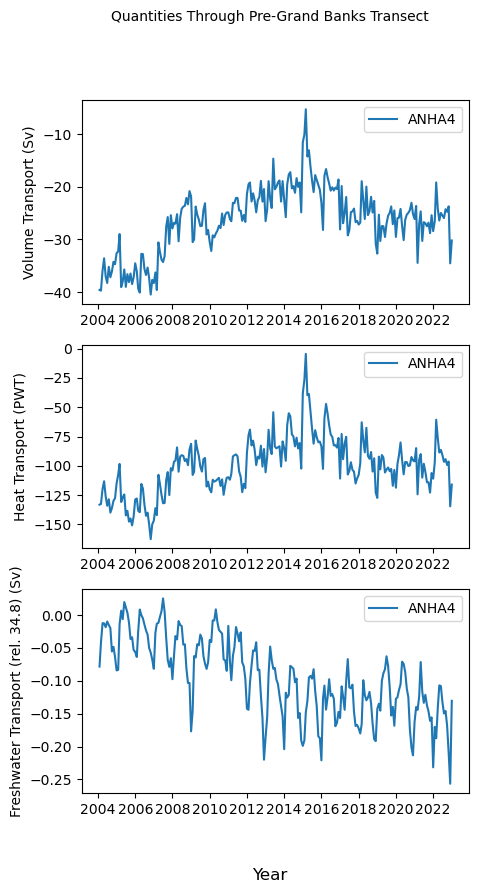

In [11]:
fig, axes = plt.subplots(3,1, figsize=(5,9))

axes[0].plot(vol4.time_counter.values.astype("datetime64[ns]"), vol4['vel'].values, label = 'ANHA4')
#axes[0].plot(vol12.time_counter.values.astype("datetime64[ns]"), vol12['vel'].values, label = 'ANHA12')
axes[0].legend()

axes[1].plot(vol4.time_counter.values.astype("datetime64[ns]"), h4['__xarray_dataarray_variable__'].values, label = 'ANHA4') # heat transport
#axes[1].plot(vol12.time_counter.values.astype("datetime64[ns]"), vol12['heat'].values, label = 'ANHA12') # heat transport
axes[1].legend()

axes[2].plot(vol4.time_counter.values.astype("datetime64[ns]"), f4['__xarray_dataarray_variable__'].values, label = 'ANHA4') # fresh transport
#axes[2].plot(vol12.time_counter.values.astype("datetime64[ns]"), vol12['fresh'].values, label = 'ANHA12') # fresh transport
axes[2].legend()

axes[0].set_ylabel("Volume Transport (Sv)")
axes[1].set_ylabel("Heat Transport (PWT)")
axes[2].set_ylabel("Freshwater Transport (rel. 34.8) (Sv)")

fig.suptitle('Quantities Through Pre-Grand Banks Transect', fontsize=10)
fig.supxlabel("Year")

In [5]:
vol4 = xr.open_mfdataset("/mnt/storage6/grace/data/ANHA12_mesh_zgr.nc")


In [6]:
vol4

<xarray.Dataset> Size: 3GB
Dimensions:       (y: 2400, x: 1632, z: 50, t: 1)
Dimensions without coordinates: y, x, z, t
Data variables: (12/18)
    nav_lon       (y, x) float32 16MB dask.array<chunksize=(761, 515), meta=np.ndarray>
    nav_lat       (y, x) float32 16MB dask.array<chunksize=(761, 515), meta=np.ndarray>
    nav_lev       (z) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
    time_counter  (t) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    mbathy        (t, y, x) int16 8MB dask.array<chunksize=(1, 795, 537), meta=np.ndarray>
    e3t_ps        (t, y, x) float64 31MB dask.array<chunksize=(1, 397, 268), meta=np.ndarray>
    ...            ...
    e3w_0         (t, z) float64 400B dask.array<chunksize=(1, 50), meta=np.ndarray>
    tmask         (t, z, y, x) int8 196MB dask.array<chunksize=(1, 13, 600, 408), meta=np.ndarray>
    e3t           (t, z, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
    e3u           (t, z, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
    e3v           (t, z, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
    e3w           (t, z, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
Attributes:
    file_name:  mesh_zgr.nc
    TimeStamp:  23/06/2016 19:52:03 -0600
    history:    Wed Jan 18 17:37:07 2017: ncks -A -v e3w mesh_mask.nc ANHA12_...
    NCO:        4.4.4

In [ ]:
vol3 = xr.open_mfdataset("/mnt/storage6/grace/data/ANHA12_mesh_hgr.nc")
vol3

In [3]:
ds_t12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d25_gridT.nc")
ds_u12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d25_gridU.nc")
ds_v12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d25_gridV.nc")

In [4]:
ds_t12

<xarray.Dataset> Size: 6GB
Dimensions:       (y: 2400, x: 1632, time_counter: 1, deptht: 50)
Coordinates:
  * time_counter  (time_counter) float32 4B 7.56e+07
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
Dimensions without coordinates: y, x
Data variables:
    nav_lon       (y, x) float32 16MB dask.array<chunksize=(1200, 816), meta=np.ndarray>
    nav_lat       (y, x) float32 16MB dask.array<chunksize=(1200, 816), meta=np.ndarray>
    votemper      (time_counter, deptht, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
    vosaline      (time_counter, deptht, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
    sossheig      (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 1200, 816), meta=np.ndarray>
    somxl010      (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 1200, 816), meta=np.ndarray>
    sohmld        (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 1200, 816), meta=np.ndarray>
    TRC01         (time_counter, deptht, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
    TRC02         (time_counter, deptht, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
    TRC03         (time_counter, deptht, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
    TRC04         (time_counter, deptht, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
    TRC05         (time_counter, deptht, y, x) float32 783MB dask.array<chunksize=(1, 8, 400, 272), meta=np.ndarray>
Attributes:
    Conventions:  GDT 1.3
    file_name:    ANHA12-EXH006_y2019m05d25_gridT.nc
    production:   OPA9.0 beta
    TimeStamp:    2020-JAN-30 18:16:01 GMT-0500

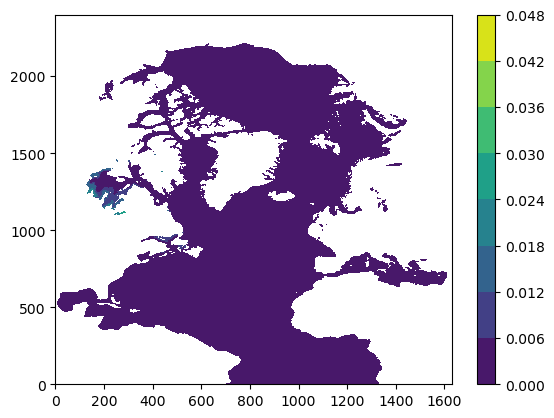

In [141]:
plt.contourf(ds_t12["TRC02"][0,23,:,:])
plt.colorbar()